Problem 1 (about Canonical Problem 1)

Derive and plot (for a fixed moment in time) the steady-state response of a semi-infinite beam subject to an oscillatory load at the boundary with a relatively small excitation frequency as well as with a relatively large excitation frequency (as compared to the cut-off frequency). Interpret the result.

In [4]:
import numpy as np 
import matplotlib.pyplot as plt

EI = 1.0   # Bending stiffness
rhoa = 1.0    # Mass per unit length
k_f = 1.0  # Foundation stiffness
omega_c = np.sqrt(k_f / rhoa) # Cut-off frequency

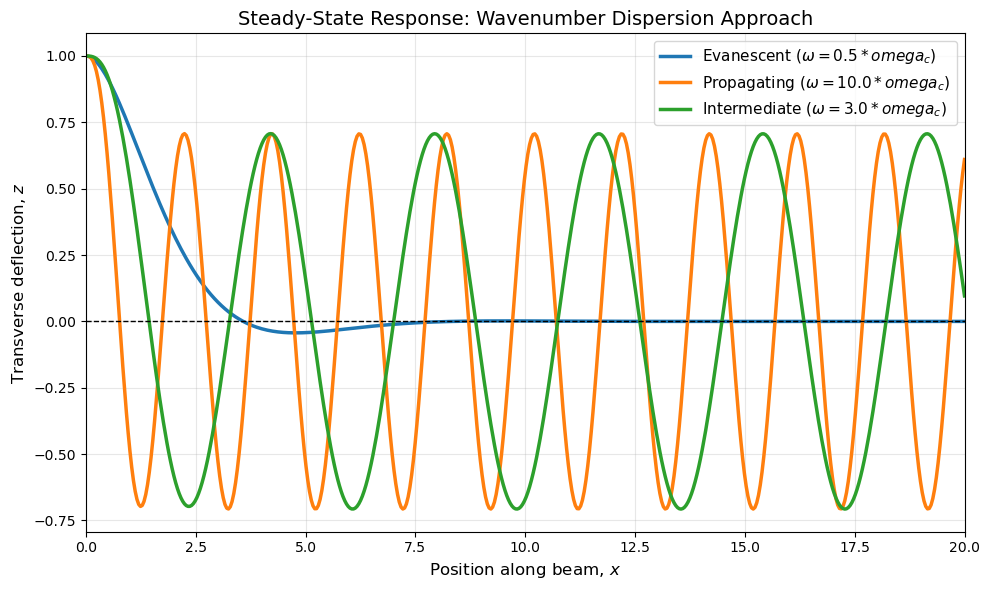

In [5]:

# Define the 2D spatial domain (x positive to the right)
x = np.linspace(0, 20, 500)
t = 0.0 # Fixed moment in time for plotting

# ---------------------------------------------------------
# 2. Dispersion Analysis & Response Function
# ---------------------------------------------------------
def compute_steady_state(omega, x_domain, t_val):
    # Dispersion relation: k^4 = (m*omega^2 - k_f) / EI
    k_4 = (rhoa * omega**2 - k_f) / EI
    
    # Find the four complex roots for wavenumber k
    # Solving the polynomial: k^4 + 0*k^3 + 0*k^2 + 0*k - k_4 = 0
    roots = np.roots([1, 0, 0, 0, -k_4])
    
    # Filter roots for a semi-infinite beam (x -> +infinity)
    # The spatial term is exp(-i*k*x). Let k = a + ib. 
    # exp(-i*(a+ib)*x) = exp(-i*a*x) * exp(b*x)
    valid_k = []
    for k in roots:
        # Condition 1: Evanescent decay (Im(k) < 0 -> b < 0)
        if np.imag(k) < -1e-6: 
            valid_k.append(k)
        # Condition 2: Right-traveling propagation (Im(k) == 0 and Re(k) > 0)
        elif abs(np.imag(k)) < 1e-6 and np.real(k) > 1e-6:
            valid_k.append(k)
            
    # We now have exactly 2 valid wave numbers for the boundary value problem
    k1, k2 = valid_k[0], valid_k[1]
    
    # ---------------------------------------------------------
    # 3. Apply Boundary Conditions at x=0
    # ---------------------------------------------------------
    # Enforce a unit displacement and zero rotation at the boundary:
    # z(0, t) = 1  => C1 + C2 = 1
    # dz/dx(0, t) = 0 => -i*k1*C1 - i*k2*C2 = 0 => k1*C1 + k2*C2 = 0
    
    A = np.array([[1, 1], 
                  [k1, k2]])
    b = np.array([1, 0])
    
    # Solve for the complex amplitudes
    C = np.linalg.solve(A, b)
    
    # Compute the full complex spatial-temporal profile
    # z(x,t) = Re( (C1*exp(-i*k1*x) + C2*exp(-i*k2*x)) * exp(i*omega*t) )
    z_complex = C[0] * np.exp(-1j * k1 * x_domain) + C[1] * np.exp(-1j * k2 * x_domain)
    z_real = np.real(z_complex * np.exp(1j * omega * t_val))
    
    return z_real

# ---------------------------------------------------------
# 4. Evaluation and Visualization
# ---------------------------------------------------------
# Define frequencies below and above the cut-off
omega_low = 0.5 * omega_c  
omega_high = 10.0 * omega_c 
omega_littlehigh = 3.0 * omega_c

# Compute transverse deflections (z-axis)
z_low = compute_steady_state(omega_low, x, t)
z_high = compute_steady_state(omega_high, x, t)
z_littlehigh = compute_steady_state(omega_littlehigh, x, t)

# Plotting using Matplotlib
plt.figure(figsize=(10, 6))

# Plot responses
plt.plot(x, z_low, label=f'Evanescent ($\\omega = {omega_low:.1f} * omega_c$)', linewidth=2.5, color='#1f77b4')
plt.plot(x, z_high, label=f'Propagating ($\\omega = {omega_high:.1f} * omega_c$)', linewidth=2.5, color='#ff7f0e')
plt.plot(x, z_littlehigh, label=f'Intermediate ($\\omega = {omega_littlehigh:.1f} * omega_c$)', linewidth=2.5, color='#2ca02c')

# Formatting the 2D plane (x-axis and z-axis)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlim(0, 20)
plt.xlabel('Position along beam, $x$', fontsize=12)
plt.ylabel('Transverse deflection, $z$', fontsize=12)
plt.title('Steady-State Response: Wavenumber Dispersion Approach', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Problem 2 (about Canonical Problem 1)


Consider an infinite beam with continuous visco-elastic foundation, subject to a constant moving load. The equation of motion reads as follows (η denotes the distributed-dashpot constant; other symbols have the same meaning as in the lecture slides of Canonical Problem 1):

$$\rho A \frac{\partial^2 w}{\partial t^2} + EI \frac{\partial^4 w}{\partial x^4} + \chi w + \eta \frac{\partial w}{\partial t} = Q_0 \delta(x - Vt)$$

Derive and compute the steady-state response in the moving reference system for a sub-critical velocity (note that the critical velocity is approximately the same as that of the undamped system) and plot the result for the following parameter values:

It is advised to take the integral over frequency numerically, for example using the Trapezium rule (which is most easy). In doing so, make sure you respect the sampling theorem related to the discrete Fourier transform. The use of Maple to conduct the numerical integration is in this case not advised, as the result is very sensitive to the precise settings (accuracy, discretization, etc.).

In [6]:
rho_A = 268.3 #kg/m
EI = 6.42*10**6 #N*m^2
chi = 7.3*10**6 #N/m^2
eta = 100 #distributed dashpot Ns/m^2 
Q_0 = 80000 #N 

Calculated Critical Velocity: 225.90 m/s


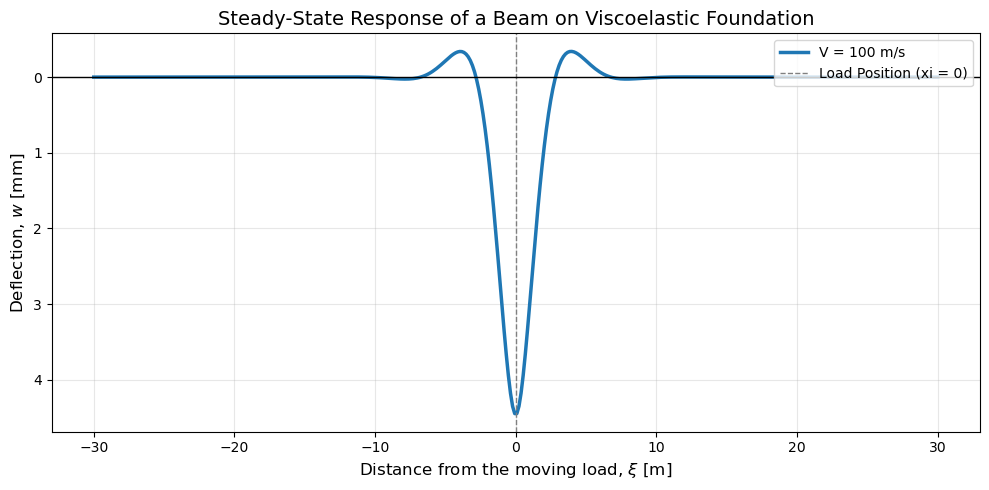

In [7]:
V_cr = np.sqrt(2 * np.sqrt(EI * chi) / rho_A)
print(f"Calculated Critical Velocity: {V_cr:.2f} m/s")
V = 100

dk = 0.01 
k_max = 20
k = np.arange(-k_max, k_max, dk)

# Evaluate w_tilde(k) based on the derived Fourier transform
denominator = EI * k**4 - rho_A * V**2 * k**2 + chi - 1j * eta * V * k
w_tilde = Q_0 / denominator

# Define the spatial coordinate array (moving coordinate xi = x - Vt)
xi_array = np.linspace(-30, 30, 400)
w_xi = np.zeros_like(xi_array, dtype=complex)

for j, xi in enumerate(xi_array):
    integrand = w_tilde * np.exp(1j * k * xi)
    w_xi[j] = np.trapezoid(integrand, k) / (2 * np.pi)
    
w_real = np.real(w_xi)

plt.figure(figsize=(10, 5))
# Multiply by 1000 to show deflection in millimeters
plt.plot(xi_array, w_real * 1000, color='#1f77b4', linewidth=2.5, label=f'V = {V} m/s')

# Formatting the plot
plt.axvline(0, color='gray', linestyle='--', linewidth=1, label='Load Position (xi = 0)')
plt.axhline(0, color='black', linewidth=1)
plt.gca().invert_yaxis() # Invert y-axis standard in civil eng. so downward deflection is positive (down) visually
plt.title('Steady-State Response of a Beam on Viscoelastic Foundation', fontsize=14)
plt.xlabel('Distance from the moving load, $\\xi$ [m]', fontsize=12)
plt.ylabel('Deflection, $w$ [mm]', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3. For the same problem considered in the previous question, derive and compute the equivalent stiffness at the loading/contact point and plot it versus velocity. Consider in the plot only the sub-critical velocity range (up to the 99% of the critical velocity) and explain what you observe.

C:\Users\jwcho\AppData\Local\Temp\ipykernel_18040\1202269402.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  K_eq[i] = 1 / compliance


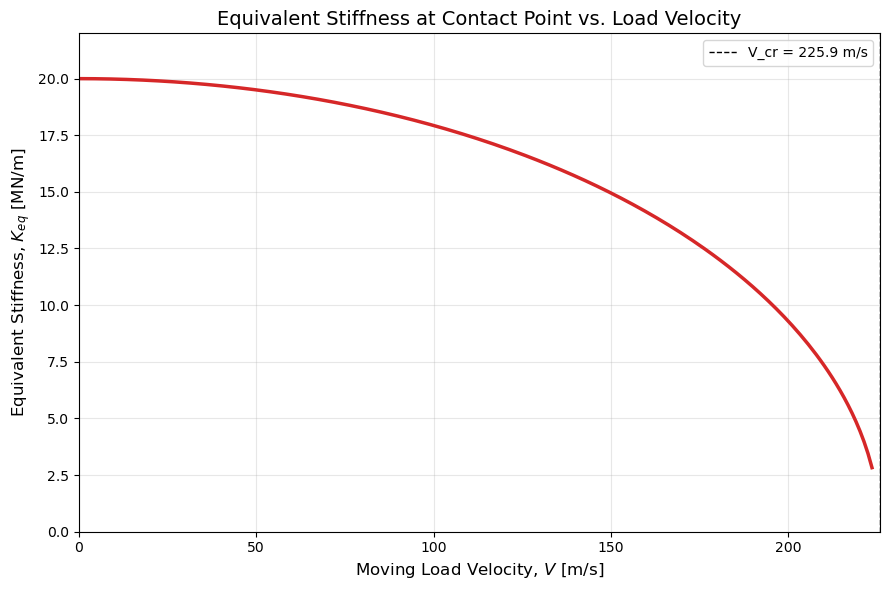

In [8]:
V_array = np.linspace(0, 0.99 * V_cr, 200)

dk = 0.001
k_max = 20 
k = np.arange(-k_max, k_max, dk)

K_eq = np.zeros_like(V_array)

for i, V in enumerate(V_array):
    denominator = EI * k**4 - rho_A * V**2 * k**2 + chi - 1j * eta * V * k
    compliance_integrand = 1 / denominator
    compliance = np.trapezoid(compliance_integrand, k) / (2 * np.pi)
    K_eq[i] = 1 / compliance
    

plt.figure(figsize=(9, 6))

plt.plot(V_array, K_eq / 1e6, color='#d62728', linewidth=2.5)

plt.axvline(V_cr, color='black', linestyle='--', linewidth=1, label=f'V_cr = {V_cr:.1f} m/s')
plt.title('Equivalent Stiffness at Contact Point vs. Load Velocity', fontsize=14)
plt.xlabel('Moving Load Velocity, $V$ [m/s]', fontsize=12)
plt.ylabel('Equivalent Stiffness, $K_{eq}$ [MN/m]', fontsize=12)
plt.xlim(0, V_cr)
plt.ylim(0, np.max(K_eq) * 1.1 / 1e6)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

4. Consider a beam with continuous visco-elastic foundation having finite length and being simply supported at the edges, and excited by a constant moving load. Derive and compute the response of the structure and plot the response for a number of time moments (include one with t > L/V). Explain the observed behaviour (in terms of steady state and transient effects). Use the same parameter values as in Problem 2, take the velocity of the load 0.75 times the critical speed of the infinite beam with distributed elastic foundation and assume the length sufficiently long so that the steady-state profile of the infinite beam under the same load can develop (e.g., 100 m); include as many modes as needed for convergence (if needed, increase the value of η to make sure that the number of modes is not too large; damping decreases the importance of higher modes).

In [9]:
L = 100
V = 0.75 * V_cr
n_modes = 5 

t_0 = L/V 
t_snapshots = [0.2*t_0, 0.4*t_0, 0.6*t_0, 0.8*t_0, t_0]
labels = ['t = 0.2 L/V', 't = 0.4 L/V', 't = 0.6 L/V', 't = 0.8 L/V', 't = L/V']

x = np.linspace(0, L, 300)

def compute_qn(n, t):
    if t == 0:
        return 0 #beam is at rest
    
    Omega_m = n * np.pi * V / L 
    omega_m = np.sqrt((EI * (n * np.pi / L)**4 + chi) / rho_A)
    zeta_m = eta / (2 * rho_A * omega_m)
    omega_dm = omega_m * np.sqrt(1 - zeta_m**2)
    
    coeff = (2 * Q_0) / (rho_A * L * omega_dm)
    
    tau_upper = t if t < t_0 else t_0
    tau = np.linspace(0, tau_upper, 200)
    
    integrand = np.sin(Omega_m * tau) * np.exp(-zeta_m * omega_m * (t - tau)) * np.sin(omega_dm * (t - tau))
    
    integral = np.trapezoid(integrand, tau)
    return coeff * integral




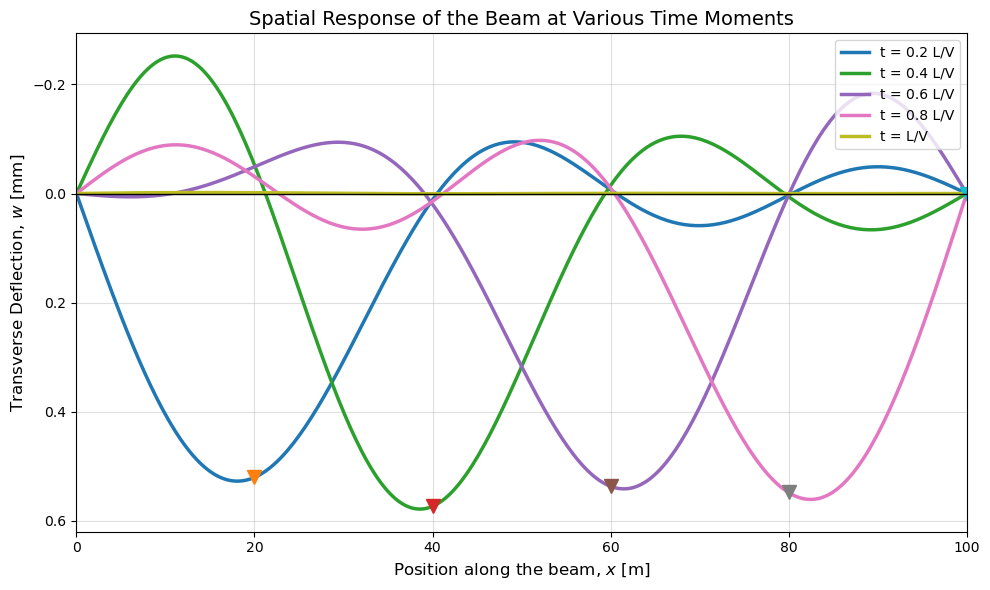

In [10]:
plt.figure(figsize=(10, 6))

# Loop through each requested time snapshot
for idx, t in enumerate(t_snapshots):
    w_x = np.zeros_like(x)
    
    # Superpose the modes for this specific time
    for i in range(n_modes):
        n = i + 1
        q_n_t = compute_qn(n, t)
        mode_shape = np.sin(n * np.pi * x / L)
        w_x += q_n_t * mode_shape
        
    # Plot the beam profile
    plt.plot(x, w_x * 1000, linewidth=2.5, label=labels[idx])
    
    # Optional: Mark the load position if it is currently on the beam
    if 0 < t <= t_0:
        load_pos = V * t
        # Find the deflection at the load position for the marker
        load_idx = np.argmin(np.abs(x - load_pos))
        plt.plot(load_pos, w_x[load_idx] * 1000, 'v', markersize=10)

# ---------------------------------------------------------
# 4. Formatting the Plot
# ---------------------------------------------------------
plt.title('Spatial Response of the Beam at Various Time Moments', fontsize=14)
plt.xlabel('Position along the beam, $x$ [m]', fontsize=12)
plt.ylabel('Transverse Deflection, $w$ [mm]', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()  # Structural convention (downward is positive)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.xlim(0, L)
plt.tight_layout()
plt.show()

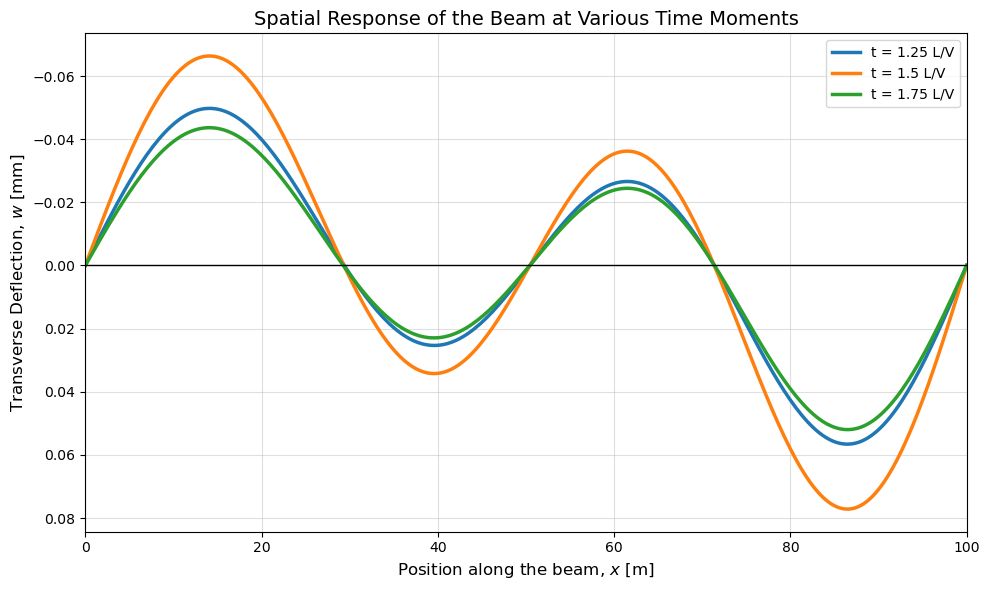

In [11]:
t_snapshots = [1.25 * t_0, 1.5 * t_0, 1.75 * t_0]
labels = ['t = 1.25 L/V', 't = 1.5 L/V', 't = 1.75 L/V']

plt.figure(figsize=(10, 6))

for idx, t in enumerate(t_snapshots):
    w_x = np.zeros_like(x)
    
    for i in range(n_modes):
        n = i + 1
        q_n_t = compute_qn(n, t)
        mode_shape = np.sin(n * np.pi * x / L)
        w_x += q_n_t * mode_shape
        
    plt.plot(x, w_x * 1000, linewidth=2.5, label=labels[idx])
    
# ---------------------------------------------------------
# 4. Formatting the Plot
# ---------------------------------------------------------
plt.title('Spatial Response of the Beam at Various Time Moments', fontsize=14)
plt.xlabel('Position along the beam, $x$ [m]', fontsize=12)
plt.ylabel('Transverse Deflection, $w$ [mm]', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()  # Structural convention (downward is positive)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.xlim(0, L)
plt.tight_layout()
plt.show()

5. Consider an overhead powerline structure of a railway track, which is modelled as an infinite tensioned string that is periodically supported by discrete springs and dashpots.

b) Derive expressions for the wavenumbers, plot the dispersion lines and interpret the result.

In [12]:
rhoa = 1.1 #kg/m
T = 15e3 #Nm^2 
L = 10 #m
k_s = 4e3 #N/m
eta_s = 0.5 #Ns/m
Q_0 = 55 #N
V = 28 #m/s

<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
C:\Users\jwcho\AppData\Local\Temp\ipykernel_18040\3241680217.py:31: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Frequency $\omega$ (rad/s)', fontsize=12)


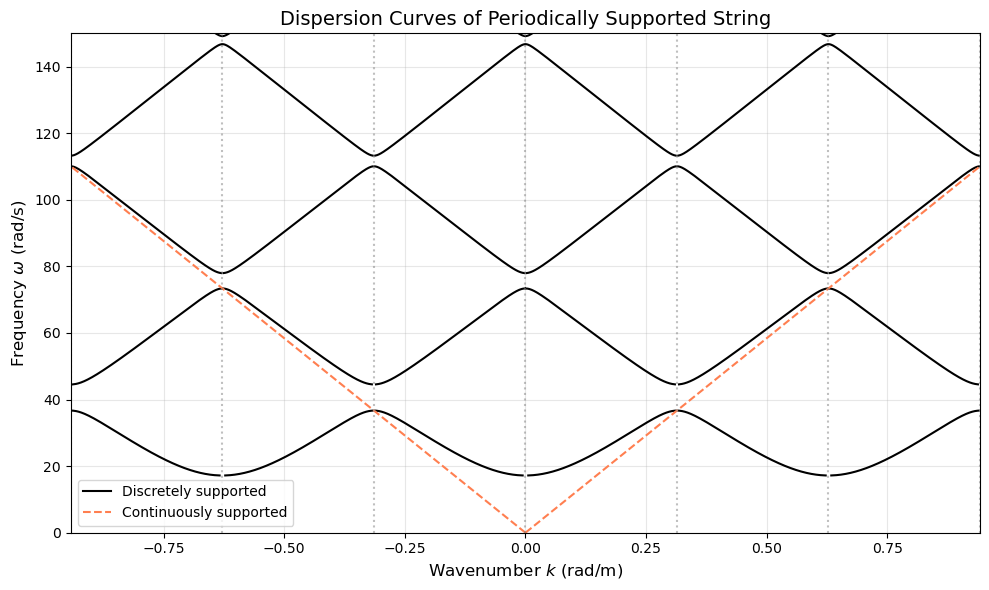

In [13]:
omega = np.linspace(0.01, 150, 5000)
kappa = omega / np.sqrt(T/rhoa)
RHS = np.cos(kappa*L) + (k_s / (2*T*kappa)) * np.sin(kappa*L)
RHS_masked = np.where(np.abs(RHS) <= 1, RHS, np.nan)

kL = np.arccos(RHS_masked)
k_real = np.real(kL) / L
k_cont = kappa 

plt.figure(figsize=(10, 6))

for n in range(-3, 4):
    k_shift = k_real + (2 * np.pi * n) / L 
    k_shift_neg = -k_real + (2 * np.pi * n) / L
    
    if n == 0: 
        plt.plot(k_shift, omega, 'k-', linewidth=1.5, label='Discretely supported')
        plt.plot(k_shift_neg, omega, 'k-', linewidth=1.5)
    else:
        plt.plot(k_shift, omega, 'k-', linewidth=1.5)
        plt.plot(k_shift_neg, omega, 'k-', linewidth=1.5)


# Plot Continuous system (orange/red dashed line)
plt.plot(k_cont, omega, color='coral', linestyle='--', linewidth=1.5, label='Continuously supported')
plt.plot(-k_cont, omega, color='coral', linestyle='--', linewidth=1.5)

# Formatting the plot
plt.title('Dispersion Curves of Periodically Supported String', fontsize=14)
plt.xlabel('Wavenumber $k$ (rad/m)', fontsize=12)
plt.ylabel('Frequency $\omega$ (rad/s)', fontsize=12)

# Set axis limits to show roughly -3 to +3 Brillouin zones
k_limit = 3 * np.pi / L
plt.xlim(-k_limit, k_limit)
plt.ylim(0, 150)

# Add grid lines at Brillouin zone boundaries (multiples of pi/L)
for n in range(-3, 4):
    plt.axvline(n * np.pi / L, color='gray', linestyle=':', alpha=0.5)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

c) Derive an expression for the steady-state response in the frequency-space domain (at x=0) and plot the corresponding amplitude spectrum (for the system with damping). Interpret the result.

<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\o'
C:\Users\jwcho\AppData\Local\Temp\ipykernel_18040\1845766771.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Frequency $\omega$ (rad/s)', fontsize=12)
C:\Users\jwcho\AppData\Local\Temp\ipykernel_18040\1845766771.py:15: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('$|\hat{w}(0, \omega)|$ (m)', fontsize=12)
C:\Users\jwcho\AppData\Local\Temp\ipykernel_18040\1845766771.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.axvline(omega_p, color='red', linestyle='--', alpha=0.6, label=f'Load Passing Freq ($\omega_p$ = {omega_p:.2f} rad/s)')


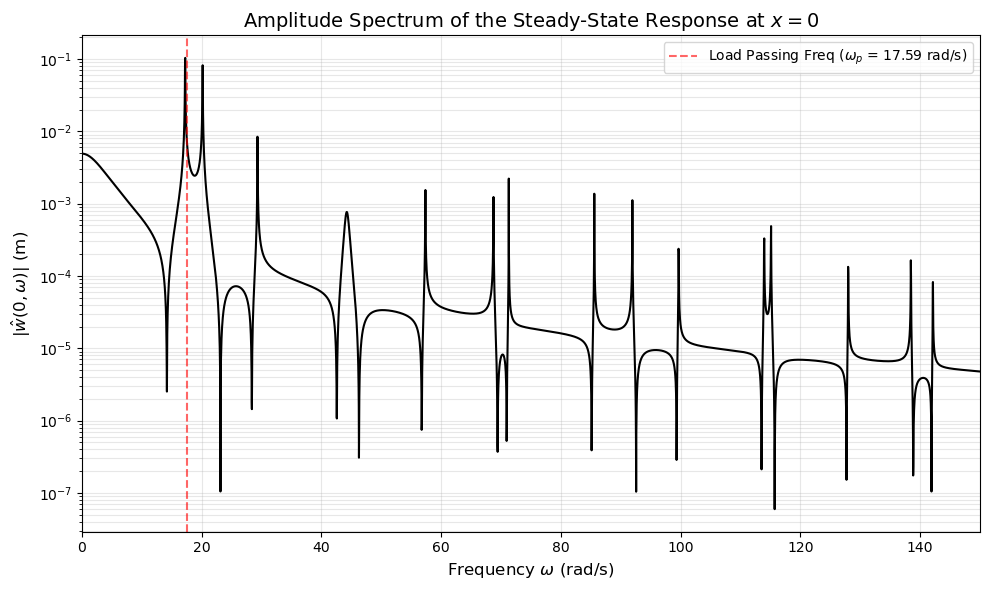

In [15]:
Zs = k_s + 1j * omega * eta_s

K_s_ml = T*V*((omega/V)**2 - kappa**2)
K_s_s = 2*T*kappa* (np.cos(kappa*L) - np.cos(omega*L/V)) /np.sin(kappa*L)
w_0_omega = (Q_0 / K_s_ml) * (K_s_s / (K_s_s + Zs)) #steady state displacement at x=0 in frequency domain
amplitude_spectrum = np.abs(w_0_omega)

plt.figure(figsize=(10, 6))

plt.plot(omega, amplitude_spectrum, 'k-', linewidth=1.5)

# Formatting the plot
plt.title('Amplitude Spectrum of the Steady-State Response at $x=0$', fontsize=14)
plt.xlabel('Frequency $\omega$ (rad/s)', fontsize=12)
plt.ylabel('$|\hat{w}(0, \omega)|$ (m)', fontsize=12)

# Calculate and plot the fundamental load passing frequency
omega_p = 2 * np.pi * V / L
plt.axvline(omega_p, color='red', linestyle='--', alpha=0.6, label=f'Load Passing Freq ($\omega_p$ = {omega_p:.2f} rad/s)')

plt.xlim(0, 150)
plt.yscale('log') # Log scale is typical for frequency response to see peaks clearly
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

d) Compute numerically the response (at x=0) versus time (make sure you respect the sampling theorem related to the discrete Fourier transform). Interpret the result.

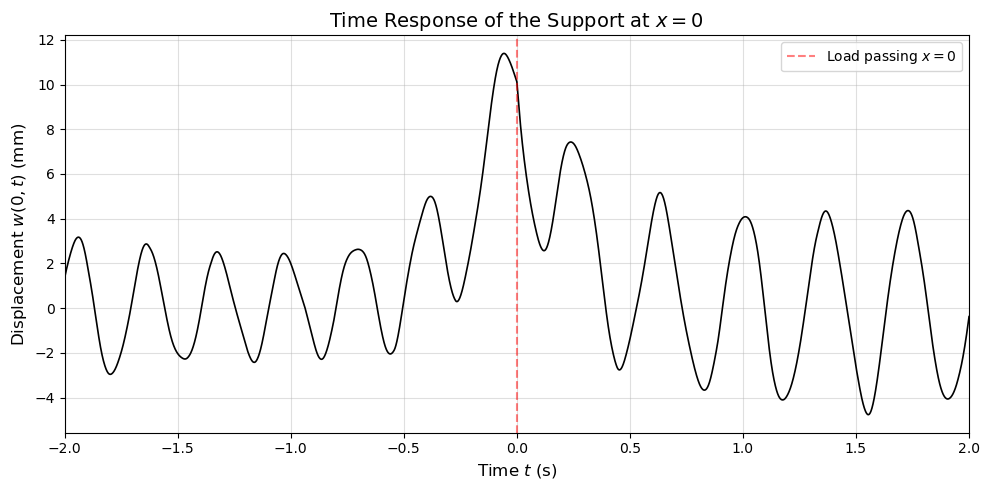

In [18]:
c = np.sqrt(T/rhoa) # Wave speed in the string

N = 2**18 
T_window = 200 
dt = T_window / N
fs = 1/dt

freqs = np.fft.fftfreq(N, d=dt)
omega = 2 * np.pi * freqs

omega[0] = 1e-12 #avoid 0 division 

kappa = omega / c
Zs = k_s + 1j * omega * eta_s
K_s_ml = T*V*((omega/V)**2 - kappa**2)
K_s_s = 2*T*kappa* (np.cos(kappa*L) - np.cos(omega*L/V)) /np.sin(kappa*L)
w_hat = (Q_0 / K_s_ml) * (K_s_s / (K_s_s + Zs))

w_t = fs * np.fft.ifft(w_hat)
w_t = np.real(w_t) 

w_t_shifted = np.fft.fftshift(w_t)
t_shifted = np.linspace(-T_window/2, T_window/2, N, endpoint=False)

plt.figure(figsize=(10, 5))
plt.plot(t_shifted, w_t_shifted * 1000, 'k-', linewidth=1.2) # Convert to mm for readability
plt.title('Time Response of the Support at $x=0$', fontsize=14)
plt.xlabel('Time $t$ (s)', fontsize=12)
plt.ylabel('Displacement $w(0, t)$ (mm)', fontsize=12)

# Zoom in on the relevant event to see the wave characteristics
plt.xlim(-2, 2) 
plt.grid(True, alpha=0.4)
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Load passing $x=0$')
plt.legend()
plt.tight_layout()
plt.show()